In [37]:
import os
import time
from itertools import combinations
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42

In [39]:
CSV_PATH = "imdb_top_1000.csv"
STAR_COLS = ["Star1", "Star2", "Star3", "Star4"]

df = pd.read_csv(CSV_PATH)
df = df[STAR_COLS].copy()
df = df.dropna(subset=STAR_COLS).copy()
for c in STAR_COLS:
    df[c] = df[c].astype(str).str.strip()
for c in STAR_COLS:
    df.loc[df[c].str.len() == 0, c] = pd.NA
df = df.dropna(subset=STAR_COLS).copy()

print("Rows after cleaning:", len(df))
print(df.head())


Rows after cleaning: 1000
            Star1           Star2          Star3           Star4
0     Tim Robbins  Morgan Freeman     Bob Gunton  William Sadler
1   Marlon Brando       Al Pacino     James Caan    Diane Keaton
2  Christian Bale    Heath Ledger  Aaron Eckhart   Michael Caine
3       Al Pacino  Robert De Niro  Robert Duvall    Diane Keaton
4     Henry Fonda     Lee J. Cobb  Martin Balsam    John Fiedler


In [40]:
baskets = [set(row) for row in df[STAR_COLS].values.tolist()]

print("Number of baskets:", len(baskets))
print("Example basket:", list(baskets[0]))

Number of baskets: 1000
Example basket: ['William Sadler', 'Morgan Freeman', 'Bob Gunton', 'Tim Robbins']


In [41]:
def pair_hash(i, j, num_buckets):
    return (i * 1000003 + j) % num_buckets

In [42]:
def run_apriori_pairs(baskets, min_support):
    """
    Returns:
      L1: set of frequent items (strings)
      L2: set of frequent pairs as tuples (a,b) sorted
      C2_distinct: number of distinct candidate pairs counted
      total_pair_occurrences: number of pair occurrences processed in pass 2
      time_sec
    """
    t0 = time.time()

    item_counts = Counter()
    for b in baskets:
        item_counts.update(b)

    L1 = {item for item, cnt in item_counts.items() if cnt >= min_support}


    pair_counts = Counter()
    total_pair_occurrences = 0

    for b in baskets:
        freq_items = [x for x in b if x in L1]
        for a, c in combinations(freq_items, 2):
            pair_counts[tuple(sorted((a, c)))] += 1
            total_pair_occurrences += 1

    L2 = {pair for pair, cnt in pair_counts.items() if cnt >= min_support}

    t1 = time.time()

    return {
        "L1": L1,
        "L2": L2,
        "C2_distinct": len(pair_counts),
        "total_pair_occurrences": total_pair_occurrences,
        "time_sec": t1 - t0,
    }


In [43]:
def run_pcy_pairs(baskets, min_support, num_buckets):
    """
    PCY (2-pass) for frequent pairs:
      Pass1: count items + hash bucket counts for all pairs in each basket
      Build bitmap of frequent buckets
      Pass2: count candidate pairs = pairs of frequent items that hash to frequent bucket
    Returns:
      L1, L2, C2_distinct, frequent_buckets (#), time_sec
    """
    t0 = time.time()


    item_counts = Counter()
    bucket_counts = [0] * num_buckets

    for b in baskets:
        item_counts.update(b)
        items = list(b)
        for a, c in combinations(items, 2):
            pass


    all_items = list(item_counts.keys())
    item2id = {it: idx for idx, it in enumerate(all_items)}


    bucket_counts = [0] * num_buckets
    for b in baskets:
        items = [item2id[x] for x in b]
        items.sort()
        for i, j in combinations(items, 2):
            h = pair_hash(i, j, num_buckets)
            bucket_counts[h] += 1


    L1 = {item for item, cnt in item_counts.items() if cnt >= min_support}
    frequent_item_ids = {item2id[x] for x in L1}


    bitmap = [1 if c >= min_support else 0 for c in bucket_counts]
    frequent_buckets = sum(bitmap)


    pair_counts = Counter()

    for b in baskets:

        freq_items = [x for x in b if x in L1]

        ids = sorted(item2id[x] for x in freq_items)


        for i, j in combinations(ids, 2):
            h = pair_hash(i, j, num_buckets)
            if bitmap[h] == 1:

                a = all_items[i]
                c = all_items[j]
                pair_counts[tuple(sorted((a, c)))] += 1

    L2 = {pair for pair, cnt in pair_counts.items() if cnt >= min_support}

    t1 = time.time()

    return {
        "L1": L1,
        "L2": L2,
        "C2_distinct": len(pair_counts),
        "frequent_buckets": frequent_buckets,
        "time_sec": t1 - t0,
    }



In [44]:
MIN_SUPPORT = 5
NUM_BUCKETS = 5000

ap = run_apriori_pairs(baskets, MIN_SUPPORT)
pcy = run_pcy_pairs(baskets, MIN_SUPPORT, NUM_BUCKETS)

print("=== Apriori ===")
print("L1:", len(ap["L1"]), " C2(distinct):", ap["C2_distinct"], " L2:", len(ap["L2"]), " time:", ap["time_sec"])
print("Frequent pairs:", ap["L2"])

print("\n=== PCY ===")
print("L1:", len(pcy["L1"]), " C2(distinct):", pcy["C2_distinct"], " L2:", len(pcy["L2"]), " time:", pcy["time_sec"])
print("Frequent buckets:", pcy["frequent_buckets"], "/", NUM_BUCKETS)
print("Frequent pairs:", pcy["L2"])

print("\nApriori == PCY L2 ?", ap["L2"] == pcy["L2"])


=== Apriori ===
L1: 79  C2(distinct): 139  L2: 3  time: 0.0017914772033691406
Frequent pairs: {('Daniel Radcliffe', 'Rupert Grint'), ('Daniel Radcliffe', 'Emma Watson'), ('Emma Watson', 'Rupert Grint')}

=== PCY ===
L1: 79  C2(distinct): 14  L2: 3  time: 0.007319927215576172
Frequent buckets: 45 / 5000
Frequent pairs: {('Daniel Radcliffe', 'Rupert Grint'), ('Daniel Radcliffe', 'Emma Watson'), ('Emma Watson', 'Rupert Grint')}

Apriori == PCY L2 ? True


In [45]:
def experiment_bucket_sweep(baskets, min_support, bucket_list):
    rows = []
    ap = run_apriori_pairs(baskets, min_support)

    for B in bucket_list:
        pcy = run_pcy_pairs(baskets, min_support, B)
        rows.append({
            "min_support": min_support,
            "num_buckets": B,
            "ap_C2_distinct": ap["C2_distinct"],
            "pcy_C2_distinct": pcy["C2_distinct"],
            "pcy_frequent_buckets": pcy["frequent_buckets"],
            "ap_L2_size": len(ap["L2"]),
            "pcy_L2_size": len(pcy["L2"]),
            "ap_time_sec": ap["time_sec"],
            "pcy_time_sec": pcy["time_sec"],
            "L2_equal": ap["L2"] == pcy["L2"],
        })
    return pd.DataFrame(rows)

bucket_list = [200, 1000, 5000, 20000, 50000]
df_bucket = experiment_bucket_sweep(baskets, min_support=5, bucket_list=bucket_list)
print("\n=== Bucket sweep results ===")
print(df_bucket.to_string(index=False))


=== Bucket sweep results ===
 min_support  num_buckets  ap_C2_distinct  pcy_C2_distinct  pcy_frequent_buckets  ap_L2_size  pcy_L2_size  ap_time_sec  pcy_time_sec  L2_equal
           5          200             139              139                   200           3            3     0.001741      0.005280      True
           5         1000             139              100                   601           3            3     0.001741      0.008216      True
           5         5000             139               14                    45           3            3     0.001741      0.006256      True
           5        20000             139                6                     9           3            3     0.001741      0.005847      True
           5        50000             139                6                     9           3            3     0.001741      0.006553      True



=== Support sweep results ===
 support  ap_L1  ap_C2_distinct  ap_L2  ap_time_sec  pcy_L1  pcy_frequent_buckets  pcy_C2_distinct  pcy_L2  pcy_time_sec  L2_equal
      10      9               9      0     0.003190       9                     0                0       0      0.025138      True
       8     17              16      0     0.009934      17                     2                0       0      0.027756      True
       7     30              32      0     0.008849      30                     4                0       0      0.034257      True
       6     59              96      1     0.011984      59                    17                7       1      0.019454      True
       5     79             139      3     0.008045      79                    45               14       3      0.025877      True
       4    145             302      5     0.012117     145                   181               66       5      0.029299      True
       3    271             622     25     0.015816 

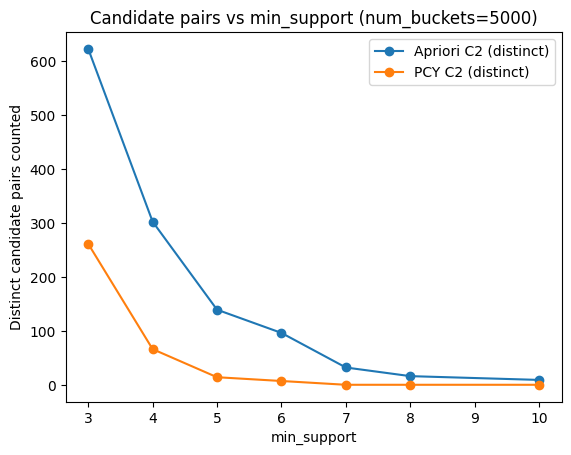

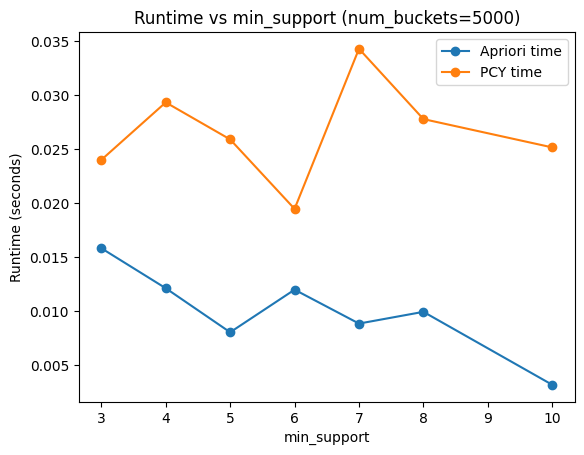

In [46]:
def experiment_support_sweep(baskets, support_list, num_buckets):
    rows = []
    for s in support_list:
        ap = run_apriori_pairs(baskets, s)
        pcy = run_pcy_pairs(baskets, s, num_buckets)
        rows.append({
            "support": s,
            "ap_L1": len(ap["L1"]),
            "ap_C2_distinct": ap["C2_distinct"],
            "ap_L2": len(ap["L2"]),
            "ap_time_sec": ap["time_sec"],
            "pcy_L1": len(pcy["L1"]),
            "pcy_frequent_buckets": pcy["frequent_buckets"],
            "pcy_C2_distinct": pcy["C2_distinct"],
            "pcy_L2": len(pcy["L2"]),
            "pcy_time_sec": pcy["time_sec"],
            "L2_equal": ap["L2"] == pcy["L2"],
        })
    return pd.DataFrame(rows)

support_list = [10, 8, 7, 6, 5, 4, 3]
NUM_BUCKETS_FIXED = 5000
df_support = experiment_support_sweep(baskets, support_list, NUM_BUCKETS_FIXED)

print("\n=== Support sweep results ===")
print(df_support.sort_values("support", ascending=False).to_string(index=False))


df_plot = df_support.sort_values("support")
plt.figure()
plt.plot(df_plot["support"], df_plot["ap_C2_distinct"], marker="o", label="Apriori C2 (distinct)")
plt.plot(df_plot["support"], df_plot["pcy_C2_distinct"], marker="o", label="PCY C2 (distinct)")
plt.xlabel("min_support")
plt.ylabel("Distinct candidate pairs counted")
plt.title(f"Candidate pairs vs min_support (num_buckets={NUM_BUCKETS_FIXED})")
plt.legend()
plt.show()


plt.figure()
plt.plot(df_plot["support"], df_plot["ap_time_sec"], marker="o", label="Apriori time")
plt.plot(df_plot["support"], df_plot["pcy_time_sec"], marker="o", label="PCY time")
plt.xlabel("min_support")
plt.ylabel("Runtime (seconds)")
plt.title(f"Runtime vs min_support (num_buckets={NUM_BUCKETS_FIXED})")
plt.legend()
plt.show()



=== Scale-only (support fixed) ===
 scale_factor  num_baskets  ap_time_sec  pcy_time_sec  ap_C2_distinct  pcy_C2_distinct  pcy_frequent_buckets  L2_equal
            1         1000     0.003850      0.006474             622              261                   631      True
            2         2000     0.005375      0.013029            1516             1096                  1717      True
            5         5000     0.028819      0.054944            5833             5833                  3391      True
           10        10000     0.049623      0.102421            5833             5833                  3391      True


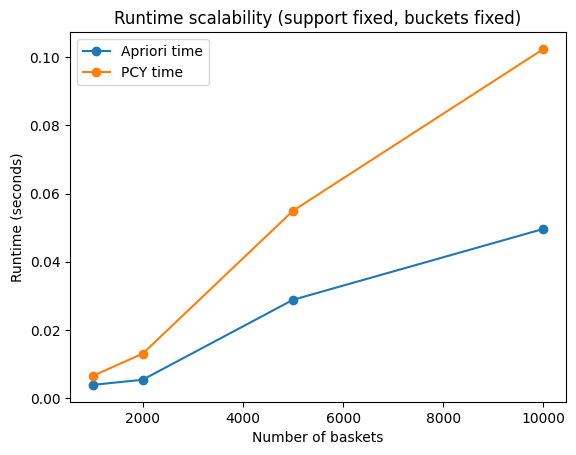

In [47]:
def experiment_scale_only(baskets, scale_factors, min_support, num_buckets):
    rows = []
    for k in scale_factors:
        baskets_big = baskets * k
        ap = run_apriori_pairs(baskets_big, min_support)
        pcy = run_pcy_pairs(baskets_big, min_support, num_buckets)
        rows.append({
            "scale_factor": k,
            "num_baskets": len(baskets_big),
            "ap_time_sec": ap["time_sec"],
            "pcy_time_sec": pcy["time_sec"],
            "ap_C2_distinct": ap["C2_distinct"],
            "pcy_C2_distinct": pcy["C2_distinct"],
            "pcy_frequent_buckets": pcy["frequent_buckets"],
            "L2_equal": ap["L2"] == pcy["L2"],
        })
    return pd.DataFrame(rows)

scale_factors = [1, 2, 5, 10]
df_scale_only = experiment_scale_only(baskets, scale_factors, min_support=3, num_buckets=5000)
print("\n=== Scale-only (support fixed) ===")
print(df_scale_only.to_string(index=False))

plt.figure()
plt.plot(df_scale_only["num_baskets"], df_scale_only["ap_time_sec"], marker="o", label="Apriori time")
plt.plot(df_scale_only["num_baskets"], df_scale_only["pcy_time_sec"], marker="o", label="PCY time")
plt.xlabel("Number of baskets")
plt.ylabel("Runtime (seconds)")
plt.title("Runtime scalability (support fixed, buckets fixed)")
plt.legend()
plt.show()

In [48]:
def experiment_scale_buckets(baskets, scale_factors, min_support, base_buckets):
    rows = []
    for k in scale_factors:
        baskets_big = baskets * k
        num_buckets = base_buckets * k
        ap = run_apriori_pairs(baskets_big, min_support)
        pcy = run_pcy_pairs(baskets_big, min_support, num_buckets)
        rows.append({
            "scale_factor": k,
            "num_baskets": len(baskets_big),
            "num_buckets": num_buckets,
            "ap_time_sec": ap["time_sec"],
            "pcy_time_sec": pcy["time_sec"],
            "ap_C2_distinct": ap["C2_distinct"],
            "pcy_C2_distinct": pcy["C2_distinct"],
            "pcy_frequent_buckets": pcy["frequent_buckets"],
            "L2_equal": ap["L2"] == pcy["L2"],
        })
    return pd.DataFrame(rows)

df_scale_buckets = experiment_scale_buckets(baskets, scale_factors, min_support=3, base_buckets=5000)
print("\n=== Scale + buckets (support fixed) ===")
print(df_scale_buckets.to_string(index=False))




=== Scale + buckets (support fixed) ===
 scale_factor  num_baskets  num_buckets  ap_time_sec  pcy_time_sec  ap_C2_distinct  pcy_C2_distinct  pcy_frequent_buckets  L2_equal
            1         1000         5000     0.004804      0.007374             622              261                   631      True
            2         2000        10000     0.005336      0.012515            1516              839                  1136      True
            5         5000        25000     0.032009      0.053276            5833             5833                  4691      True
           10        10000        50000     0.049936      0.108120            5833             5833                  4691      True



=== Support scaled with data (proper scalability) ===
          mode  scale_factor  num_baskets  min_support  num_buckets  ap_C2_distinct  pcy_C2_distinct  pcy_frequent_buckets  ap_time_sec  pcy_time_sec  L2_equal
 fixed_buckets             1         1000            3         5000             622              261                   631     0.002283      0.006047      True
scaled_buckets             1         1000            3         5000             622              261                   631     0.002215      0.007215      True
 fixed_buckets             2         2000            6         5000             622              261                   631     0.004592      0.012165      True
scaled_buckets             2         2000            6        10000             622              146                   226     0.003977      0.010869      True
 fixed_buckets             5         5000           15         5000             622              261                   631     0.009467      0.02

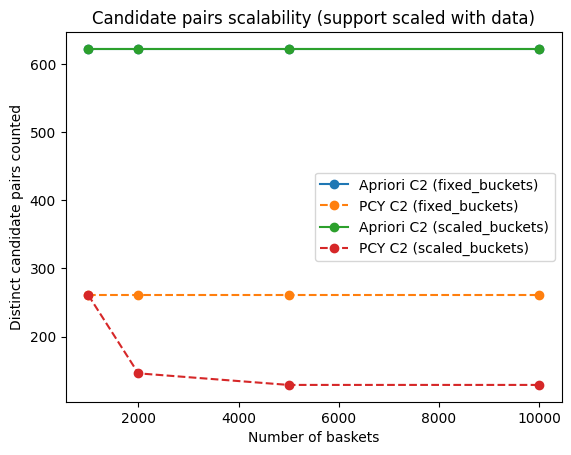

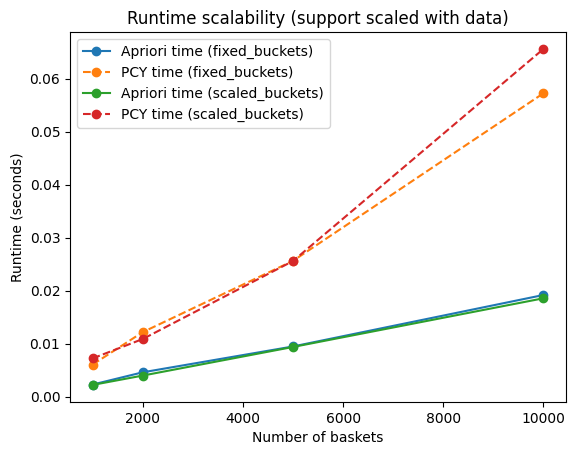

In [49]:
def experiment_support_scaled(baskets, scale_factors, base_support, base_buckets):
    rows = []
    for k in scale_factors:
        baskets_big = baskets * k
        min_support = base_support * k

        for mode in ["fixed_buckets", "scaled_buckets"]:
            if mode == "fixed_buckets":
                num_buckets = base_buckets
            else:
                num_buckets = base_buckets * k

            ap = run_apriori_pairs(baskets_big, min_support)
            pcy = run_pcy_pairs(baskets_big, min_support, num_buckets)

            rows.append({
                "mode": mode,
                "scale_factor": k,
                "num_baskets": len(baskets_big),
                "min_support": min_support,
                "num_buckets": num_buckets,
                "ap_C2_distinct": ap["C2_distinct"],
                "pcy_C2_distinct": pcy["C2_distinct"],
                "pcy_frequent_buckets": pcy["frequent_buckets"],
                "ap_time_sec": ap["time_sec"],
                "pcy_time_sec": pcy["time_sec"],
                "L2_equal": ap["L2"] == pcy["L2"],
            })
    return pd.DataFrame(rows)

df_support_scaled = experiment_support_scaled(
    baskets=baskets,
    scale_factors=scale_factors,
    base_support=3,
    base_buckets=5000
)

print("\n=== Support scaled with data (proper scalability) ===")
print(df_support_scaled.to_string(index=False))


plt.figure()
for mode in ["fixed_buckets", "scaled_buckets"]:
    d = df_support_scaled[df_support_scaled["mode"] == mode]
    plt.plot(d["num_baskets"], d["ap_C2_distinct"], marker="o", label=f"Apriori C2 ({mode})")
    plt.plot(d["num_baskets"], d["pcy_C2_distinct"], marker="o", linestyle="--", label=f"PCY C2 ({mode})")
plt.xlabel("Number of baskets")
plt.ylabel("Distinct candidate pairs counted")
plt.title("Candidate pairs scalability (support scaled with data)")
plt.legend()
plt.show()


plt.figure()
for mode in ["fixed_buckets", "scaled_buckets"]:
    d = df_support_scaled[df_support_scaled["mode"] == mode]
    plt.plot(d["num_baskets"], d["ap_time_sec"], marker="o", label=f"Apriori time ({mode})")
    plt.plot(d["num_baskets"], d["pcy_time_sec"], marker="o", linestyle="--", label=f"PCY time ({mode})")
plt.xlabel("Number of baskets")
plt.ylabel("Runtime (seconds)")
plt.title("Runtime scalability (support scaled with data)")
plt.legend()
plt.show()


In [50]:
os.makedirs("results", exist_ok=True)
df_bucket.to_csv("results/bucket_sweep.csv", index=False)
df_support.to_csv("results/support_sweep.csv", index=False)
df_scale_only.to_csv("results/scale_only.csv", index=False)
df_scale_buckets.to_csv("results/scale_buckets.csv", index=False)
df_support_scaled.to_csv("results/support_scaled.csv", index=False)

print("\nSaved CSVs in results/ folder.")


Saved CSVs in results/ folder.
